In [2]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [3]:
class AgentState(TypedDict):
    number1: int
    operation: str
    number2: int
    finalnum: int

In [4]:
def adder(state: AgentState) ->AgentState:
    """adds 2 numbers"""

    state["finalnum"] = state['number1'] + state['number2']

    return state

def sub(state: AgentState) ->AgentState:
    """subtracts 2 numbers"""

    state["finalnum"] = state['number1'] - state['number2']

    return state

def decide_node(state: AgentState) ->AgentState:
    """this node will select the next node int the graph"""
    if state["operation"]=="+":
        return "addition_operation"
    if state["operation"]=="-":
        return "subtraction_operation"

In [9]:
graph=StateGraph(AgentState)

graph.add_node("adder", adder);
graph.add_node("sub", sub);
graph.add_node("router", lambda state:state) #passthrough func

graph.add_edge(START, "router")

graph.add_conditional_edges(
    "router",
    decide_node,
    {
        #edge: node
        "add_op":"adder",
        "sub_op":"sub"
    }
)

graph.add_edge("adder", END)
graph.add_edge("sub", END)

app=graph.compile()

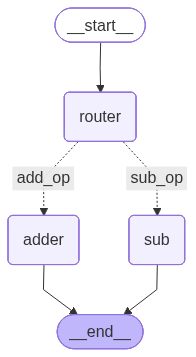

In [10]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))